# Exploratory Data Analysis - Predict Customer Churn

## About this dataset

A **telecom customer-churn** dataset: one row per customer, target = **`Churn`** (`Yes` = left, `No` = stayed). Churn = cancelling service; cutting it matters because keeping a customer is far cheaper than acquiring one.

**20 features**, in three groups:
- **Demographics** - `gender`, `SeniorCitizen`, `Partner`, `Dependents`.
- **Account** - `tenure`, `Contract`, `PaperlessBilling`, `PaymentMethod`, `MonthlyCharges`, `TotalCharges`.
- **Services** - `PhoneService`, `MultipleLines`, `InternetService` + add-ons (`OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`).

**Key facts:** classes are imbalanced (~**22.5%** churn -> evaluate with ROC-AUC / F1, not accuracy). Train = `train.csv` (~594k rows); `test.csv` is held out for one final check. This notebook does **EDA** to guide feature engineering and modelling.

## 1. Setup and data loading

In [11]:
import csv
import pandas as pd

df = pd.read_csv('train.csv')
print(f"Loaded {len(df)} rows and {len(df.columns)} columns from train.csv")

df.head(10)

Loaded 594194 rows and 21 columns from train.csv


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes
5,5,Male,0,Yes,Yes,1,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer (automatic),20.20,20.20,No
6,6,Female,0,Yes,Yes,24,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.40,533.60,No
7,7,Male,0,Yes,No,72,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,Two year,No,Electronic check,92.00,6827.50,No
8,8,Female,1,No,No,1,Yes,Yes,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,79.55,79.55,Yes
9,9,Male,0,No,No,55,Yes,No,Fiber optic,Yes,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.05,4738.30,No


## 2. Data Overview 

## 3. Data Quality Assessment

## 4. Univariate Analysis

## 5. Bivariate Analysis

### Approach

Two questions: **feature -> target** (which columns carry churn signal?) and **feature <-> feature** (redundancy). The association measure depends on the variable types:

| Pair | Visual | Strength metric |
|---|---|---|
| numeric <-> numeric | heatmap | **Pearson r** (-1..+1) |
| numeric <-> binary | histogram | **Point-biserial r** (-1..+1) |
| categorical <-> categorical | bar / heatmap | **Cramer's V** (0..1) |

> At ~594k rows significance tests are meaningless (p ~ 0 for everything), so we rank by **effect size** (|r|, Cramer's V) only.

Part A = feature -> target; Part B = feature <-> feature.

### Measure notes

- **Pearson r** - numeric<->numeric, -1..+1 signed; linear only (misses U-shapes), outlier-sensitive.
- **Point-biserial r** - numeric<->binary; Pearson on a 0/1 column, i.e. the standardized gap between the two groups' means.
- **Cramer's V** - categorical<->categorical, 0..1 unsigned; a chi-square-based effect size, bias-corrected (`cramers_v()`), not inflated by sample size.

Strength of |r| / V: <0.1 negligible, 0.1-0.3 weak, 0.3-0.5 moderate, >0.5 strong.

### 5.1 Setup

In [12]:
# =============================================================================
# 5.1  Bivariate analysis - shared setup (depends only on `df` from Section 1)
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
CHURN_PALETTE = {"No": "#4C72B0", "Yes": "#DD8452"}   # blue = stay, orange = churn

# Encode the target as 0/1 for the correlation maths.
df["Churn_binary"] = (df["Churn"] == "Yes").astype(int)
OVERALL_CHURN_RATE = df["Churn_binary"].mean()
print(f"Overall churn rate (baseline): {OVERALL_CHURN_RATE:.1%}")

NUMERIC_FEATURES = ["tenure", "MonthlyCharges", "TotalCharges"]
CATEGORICAL_FEATURES = [
    "gender", "SeniorCitizen", "Partner", "Dependents", "PhoneService",
    "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
    "Contract", "PaperlessBilling", "PaymentMethod",
]

def cramers_v(x: pd.Series, y: pd.Series) -> float:
    """Bias-corrected Cramer's V (0..1) association between two categoricals."""
    confusion = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(confusion)[0]
    n = confusion.to_numpy().sum()
    phi2 = chi2 / n
    r, k = confusion.shape
    phi2corr = max(0.0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    denom = min((kcorr - 1), (rcorr - 1))
    return np.sqrt(phi2corr / denom) if denom > 0 else np.nan

print(f"{len(NUMERIC_FEATURES)} numeric + {len(CATEGORICAL_FEATURES)} categorical features ready.")

Overall churn rate (baseline): 22.5%
3 numeric + 16 categorical features ready.


---
## Part A - Feature -> target (`Churn`)

The core question: *which columns carry a churn signal?*

### 5.2 Numeric features vs Churn

**Histograms by churn** for `tenure`, `MonthlyCharges`, `TotalCharges`, then **point-biserial r** (sign = direction, |r| = strength; ignore p at this n).

- **Reading the histograms:** density y-axis (each colour's area = 1, so the groups stay comparable). Orange (churn) mass shifted off the blue (stay) mass = the feature separates churn; heavy overlap = weak signal. The `tenure` histogram also shows churn concentrated in the first months - a non-linear effect that motivates `tenure_bin`.
- **Reading `point_biserial`:** sorted by `abs_r`; negative = more of the feature, less churn.

> **Expect:** `tenure` strongly negative, `MonthlyCharges` positive, `TotalCharges` negative. A sign opposite to this = investigate.

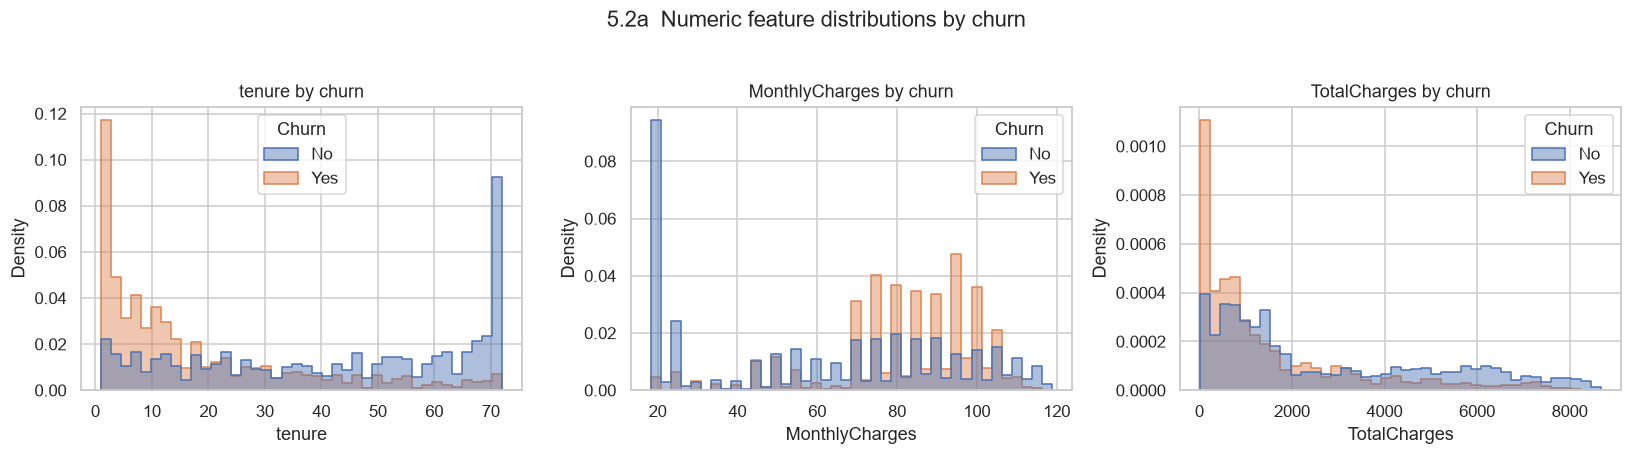

Point-biserial correlation with Churn (sorted by strength):


,feature,point_biserial_r,abs_r
0,tenure,-0.418,0.418
1,MonthlyCharges,0.273,0.273
2,TotalCharges,-0.218,0.218


In [13]:
# 5.2a  Numeric feature distributions by churn (density histograms)
fig, axes = plt.subplots(1, len(NUMERIC_FEATURES), figsize=(5 * len(NUMERIC_FEATURES), 4))
for ax, col in zip(axes, NUMERIC_FEATURES):
    sns.histplot(data=df, x=col, hue="Churn", palette=CHURN_PALETTE,
                 stat="density", common_norm=False, bins=40,
                 element="step", fill=True, alpha=0.45, ax=ax)
    ax.set_title(f"{col} by churn")
fig.suptitle("5.2a  Numeric feature distributions by churn", y=1.03)
fig.tight_layout()
plt.show()

# 5.2b  Point-biserial correlation of each numeric feature with the 0/1 target
pb_rows = []
for col in NUMERIC_FEATURES:
    r, _ = stats.pointbiserialr(df["Churn_binary"], df[col])
    pb_rows.append({"feature": col, "point_biserial_r": round(r, 3), "abs_r": round(abs(r), 3)})
point_biserial = (pd.DataFrame(pb_rows)
                  .sort_values("abs_r", ascending=False)
                  .reset_index(drop=True))
print("Point-biserial correlation with Churn (sorted by strength):")
display(point_biserial)

### 5.3 Categorical features vs Churn

**Question:** does the churn rate change across a feature's categories? Two tools: **churn-rate bars (5.3a)** and **Cramer's V (5.3b)**.

- **Reading the bars (5.3a):** each bar = one category's churn rate vs the 22.5% baseline (dashed line). Bars past it = high-risk (month-to-month, electronic check); below it = sticky (two-year); all level = irrelevant (`gender`). Wide spread = strong association.
- **Reading the table (5.3b):** rank by `cramers_v` (<0.1 negligible ... >0.5 strong); `n_levels` = number of categories.

> **Expect:** `Contract` & `PaymentMethod` top; `InternetService` / `OnlineSecurity` / `TechSupport` moderate; `gender` near zero (if it topped the list, suspect a bug or leak).

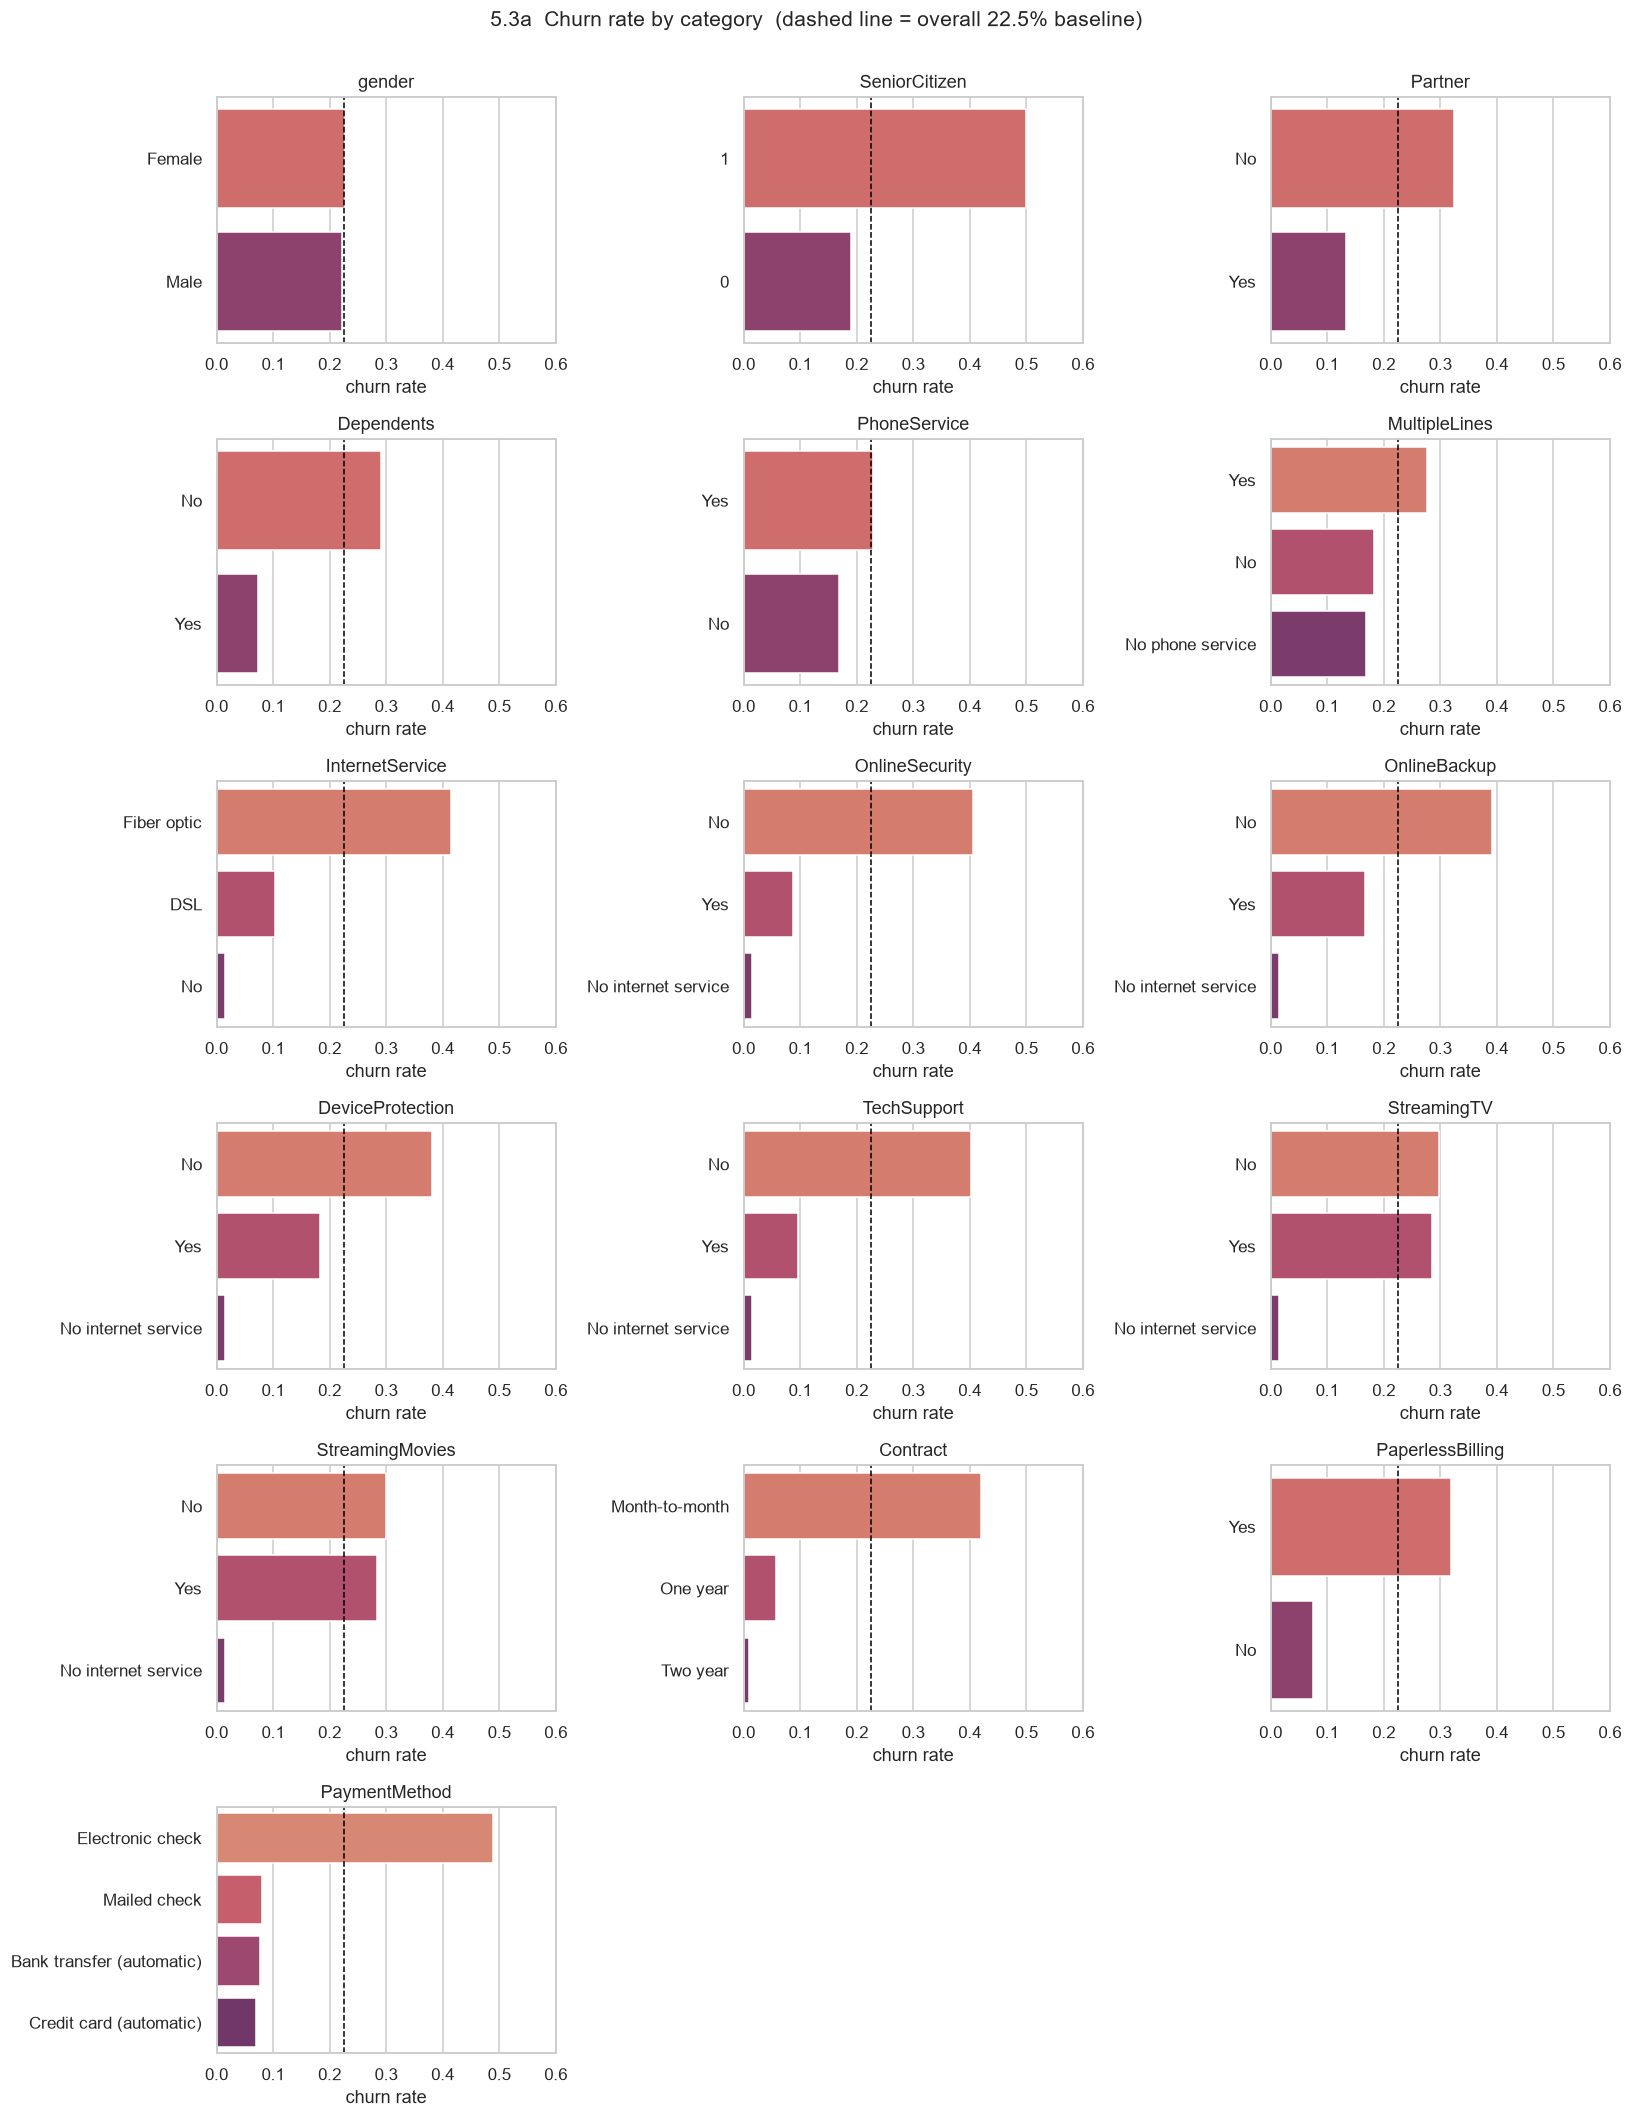

In [14]:
# -----------------------------------------------------------------------------
# 5.3a  Churn rate within each level of every categorical feature
# -----------------------------------------------------------------------------
n = len(CATEGORICAL_FEATURES)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.2 * nrows))
axes = axes.flatten()

for i, col in enumerate(CATEGORICAL_FEATURES):
    # Mean of the 0/1 target within each category == that category's churn rate.
    rates = df.groupby(col)["Churn_binary"].mean().sort_values(ascending=False)
    sns.barplot(x=rates.values, y=rates.index.astype(str),
                hue=rates.index.astype(str), legend=False,
                palette="flare", ax=axes[i])
    axes[i].axvline(OVERALL_CHURN_RATE, color="black", ls="--", lw=1)  # baseline
    axes[i].set_title(col)
    axes[i].set_xlabel("churn rate")
    axes[i].set_ylabel("")
    axes[i].set_xlim(0, max(0.6, rates.max() * 1.1))

# Hide any unused subplot panels in the grid.
for j in range(n, len(axes)):
    axes[j].axis("off")

fig.suptitle("5.3a  Churn rate by category  (dashed line = overall 22.5% baseline)",
             fontsize=14, y=1.002)
fig.tight_layout()
plt.show()

In [15]:
# 5.3b  Association strength of each categorical feature with churn (Cramer's V)
cat_rows = [{"feature": col,
             "cramers_v": round(cramers_v(df[col], df["Churn"]), 3),
             "n_levels": df[col].nunique()}
            for col in CATEGORICAL_FEATURES]
cat_assoc = (pd.DataFrame(cat_rows)
             .sort_values("cramers_v", ascending=False)
             .reset_index(drop=True))
print("Categorical features ranked by association with Churn (Cramer's V):")
display(cat_assoc)

weak = cat_assoc.iloc[-1]
print(f"Weakest: '{weak['feature']}' has Cramer's V = {weak['cramers_v']} "
      f"-> effectively no churn signal.")

Categorical features ranked by association with Churn (Cramer's V):


,feature,cramers_v,n_levels
0,PaymentMethod,0.476,4
1,Contract,0.472,3
2,OnlineSecurity,0.427,3
3,InternetService,0.426,3
4,TechSupport,0.416,3
5,OnlineBackup,0.365,3
6,DeviceProtection,0.349,3
7,PaperlessBilling,0.285,2
8,StreamingTV,0.282,3
9,StreamingMovies,0.282,3


Weakest: 'gender' has Cramer's V = 0.007 -> effectively no churn signal.


### 5.4 Every feature, ranked

Numeric (point-biserial |r|) and categorical (Cramer's V) both sit on 0-1, so we stack them into one ranked chart - the single best "what drives churn" summary.

Not quite apples-to-apples (|r| = linear only; V = any association), so treat it as a **practical ranking**, not an exact order.

**Reading it:** Sorted strongest-at-top. Bar **length** = strength; **colour** = metric (green = numeric |r|, red = Cramer's V). Dotted line at 0.10 = rough "negligible" cutoff. Top bars = best predictors; left of the line = drop candidates.

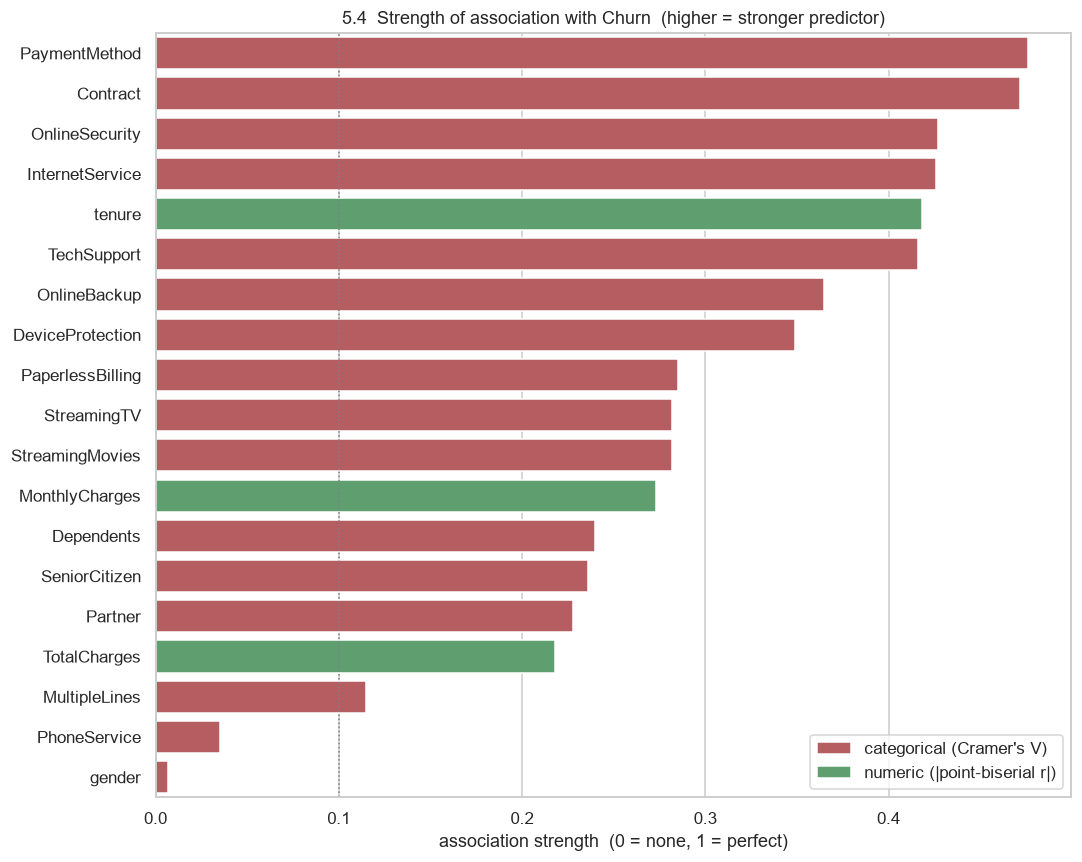

Top churn drivers: PaymentMethod, Contract, OnlineSecurity, InternetService, tenure
Negligible (candidates to drop): MultipleLines, PhoneService, gender


In [16]:
# -----------------------------------------------------------------------------
# 5.4  Combined feature -> target association ranking
# -----------------------------------------------------------------------------
# Put both metrics on the same 0..1 axis:
#   - numeric features      -> |point-biserial r|
#   - categorical features  -> Cramer's V
assoc = pd.concat([
    point_biserial.rename(columns={"abs_r": "association"})[["feature", "association"]]
                  .assign(kind="numeric (|point-biserial r|)"),
    cat_assoc.rename(columns={"cramers_v": "association"})[["feature", "association"]]
             .assign(kind="categorical (Cramer's V)"),
], ignore_index=True).sort_values("association", ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=assoc, x="association", y="feature", hue="kind", dodge=False,
            palette={"numeric (|point-biserial r|)": "#55A868",
                     "categorical (Cramer's V)": "#C44E52"})
plt.axvline(0.1, color="grey", ls=":", lw=1)   # rough "weak" threshold
plt.title("5.4  Strength of association with Churn  (higher = stronger predictor)")
plt.xlabel("association strength  (0 = none, 1 = perfect)")
plt.ylabel("")
plt.legend(title="", loc="lower right")
plt.tight_layout()
plt.show()

print("Top churn drivers:", ", ".join(assoc.head(5)["feature"]))
print("Negligible (candidates to drop):", ", ".join(assoc.tail(3)["feature"]))

---
## Part B - Feature <-> feature

Why it matters: near-duplicate features (e.g. `tenure` & `TotalCharges`) are redundant and motivate engineered features (`ChargesPerMonth`, `HasInternet`, `tenure_bin`). Less critical for the tree models than for the linear baseline.

### 5.5 Numeric <-> numeric

**Pearson heatmap** across the numerics + the 0/1 target: red ~ +1 (move together), blue ~ -1 (opposite), white ~ 0; diagonal = +1; the `Churn_binary` row = the point-biserial values from 5.2.

*Expect:* `tenure` x `TotalCharges` strongly positive (longer stay -> more spent) - the redundancy behind `ChargesPerMonth`.

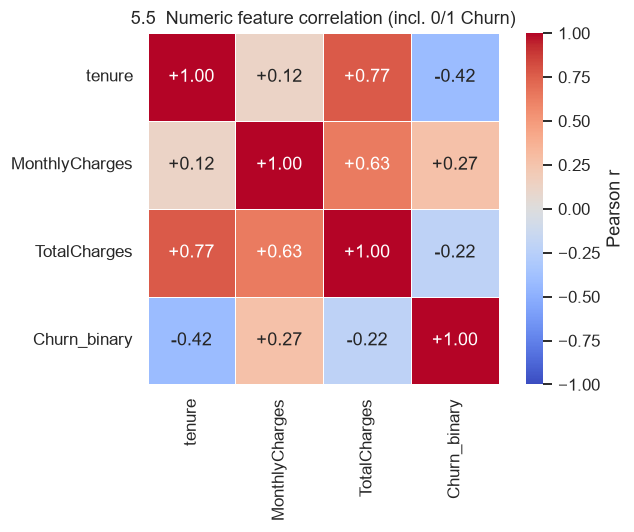

In [17]:
# 5.5  Pearson correlation among the numeric features + the 0/1 target
corr = df[NUMERIC_FEATURES + ["Churn_binary"]].corr(method="pearson")
plt.figure(figsize=(6.5, 5))
sns.heatmap(corr, annot=True, fmt="+.2f", cmap="coolwarm", center=0, vmin=-1, vmax=1,
            square=True, linewidths=.5, cbar_kws={"label": "Pearson r"})
plt.title("5.5  Numeric feature correlation (incl. 0/1 Churn)")
plt.tight_layout()
plt.show()

### 5.6 Categorical <-> categorical

The six internet add-ons (`OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`) are locked to `InternetService`: when it is `No`, all six are forced to "No internet service". The cross-tab below (rows = `InternetService`, cols = `OnlineSecurity`) shows this as **structural zeros** - the evidence for collapsing them into one `HasInternet` flag.

In [18]:
# 5.6  The six internet add-ons are locked to InternetService: confirm with a cross-tab.
print("Cross-tab: InternetService vs OnlineSecurity (counts)")
display(pd.crosstab(df["InternetService"], df["OnlineSecurity"]))

Cross-tab: InternetService vs OnlineSecurity (counts)


OnlineSecurity,No,No internet service,Yes
InternetService,,,
DSL,79318,0,101763
Fiber optic,210156,0,62230
No,0,140727,0


### 5.7 Key takeaways (slide-ready)

**Drivers:** `tenure` (low, r ~ -0.42, strongest), month-to-month `Contract` & electronic-check `PaymentMethod` (V ~ 0.47), fiber-optic `InternetService`, missing `OnlineSecurity` / `TechSupport`, higher `MonthlyCharges` (r ~ +0.27).

**No signal (drop):** `gender` (V ~ 0.007), `PhoneService` (V ~ 0.035) - "significant" p-values but trivial effect, so rank by effect size, not p.

**Redundancy -> feature engineering:** `tenure` <-> `TotalCharges` -> `ChargesPerMonth` (rate vs duration); six add-ons share "No internet service" -> `HasInternet`; non-linear tenure -> `tenure_bin`.

These three engineered features are Member 1's plan; baseline churn = 22.5%.